# Demo: Diversity Comparison

This notebook contains two sections:
1) **Code version** (replicates the current KDE-based visualization).
2) **Paper version** (implements GAD exactly as described in the paper).


## 1) Code version (KDE visualization)

This section reproduces the existing KDE visualization logic without changing the metric definition.


In [3]:
print("hihi")

hihi


FileNotFoundError: [Errno 2] No such file or directory: './proposedMetric/myUse/update/code_concentrated_kde.png'

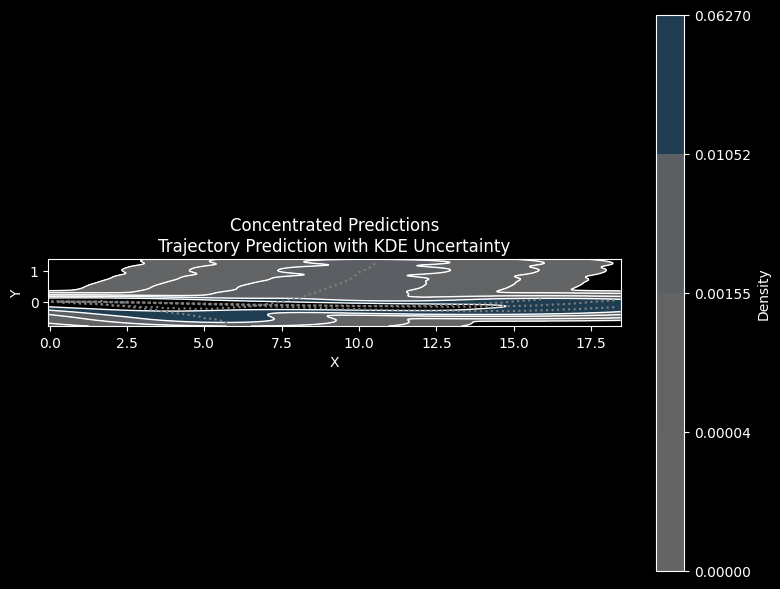

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from pathlib import Path


In [2]:

# Configuration for the two datasets
configs = [
    {
        "input": "./exampleData/scenario_1_output_imputed.pkl",
        "title": "Concentrated Predictions",
        "save": "./proposedMetric/myUse/update/code_concentrated_kde.png"
    },
    {
        "input": "./exampleData/scenario_1_output.pkl",
        "title": "Diverse Predictions",
        "save": "./proposedMetric/myUse/update/code_diverse_kde.png"
    }
]

for cfg in configs:
    # 1) Load your pickle
    with open(cfg["input"], "rb") as f:
        output = pickle.load(f)

    # 2) Extract and cast to numpy (handle tensor with .cpu())
    pred = output["predicted_trajectory"]
    try:
        import torch
        if isinstance(pred, torch.Tensor):
            pred = pred.cpu().numpy()
        else:
            pred = np.array(pred)
    except ImportError:
        pred = np.array(pred)

    # 3) Pick first scenario and XY coords
    pred0 = pred[0]         # (num_trajs, T, D)
    xy = pred0[..., :2]     # (num_trajs, T, 2)

    # 4) Build KDE over all predicted points
    points = xy.reshape(-1, 2).T  # (2, num_trajs*T)
    kde = gaussian_kde(points)

    # 5) Create grid and evaluate KDE
    xmin, ymin = points.min(axis=1) - 0.1
    xmax, ymax = points.max(axis=1) + 0.1
    X, Y = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

    # 6) (Optional) Simulate obs & gt for demo
    T = xy.shape[1]
    obs = np.stack([np.linspace(0, 1, T), np.zeros(T)], axis=1)
    gt = obs + np.sin(np.linspace(0, np.pi / 2, T))[:, None] * 0.2

    # 7) Compute the specific percentile levels
    flat = Z.ravel()
    levels = np.percentile(flat, [10, 25, 50, 75, 90])

    # 8) Plot
    fig, ax = plt.subplots(figsize=(8, 6))

    # 8.1) Filled shading
    cf = ax.contourf(X, Y, Z, levels=levels, cmap="Blues", alpha=0.4)

    # 8.2) Contour lines at percentiles
    cs = ax.contour(X, Y, Z, levels=levels, colors="white", linewidths=1)
    fig.colorbar(cf, ax=ax, label="Density")

    # 8.3) Overlay predicted trajectories
    for traj in xy:
        ax.plot(traj[:, 0], traj[:, 1], linestyle=":", color="gray")

    # 8.4) Overlay last observation
    # ax.plot(obs[:,0], obs[:,1], 'o', color='orange',
    #         linewidth=2, label='The Last Observation')

    ax.set_aspect("equal")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title(f"{cfg['title']}\nTrajectory Prediction with KDE Uncertainty")

    # save and show
    plt.tight_layout()
    Path(cfg["save"]).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(cfg["save"], dpi=300)
    plt.show()
    plt.close(fig)

NameError: name 'pickle' is not defined

## 2) Paper version (GAD)

We implement the GAD definition from the paper: for each prediction index $n$ and time step $t$,
fit a 2D GMM to the ensemble endpoints $\{(x_{t}^{(n,k)}, y_{t}^{(n,k)})\}_{k=1}^{K}$.
Collapse the GMM to a single covariance $\Sigma_t^{(n)}$, compute $\sqrt{\det(\Sigma_t^{(n)})}$,
and average over $n$ and $t$:

$$\mathrm{GAD} = \frac{1}{N T} \sum_{n=1}^{N} \sum_{t=1}^{T} \sqrt{\det(\Sigma_t^{(n)})}. $$

If the input is shaped $(K, T, D)$, it is treated as a single $n$ with $K$ samples.


In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.mixture import GaussianMixture

def _ensure_shape(pred):
    # Accept (N, K, T, D) or (K, T, D); return (N, K, T, D)
    if pred.ndim == 3:
        pred = pred[None, ...]
    return pred

def gad_score(xy, max_k=4):
    """
    xy: shape (N, K, T, 2) where
        N = prediction index (e.g., agents),
        K = ensemble samples for each prediction,
        T = time steps.
    Returns scalar GAD.
    """
    N, K, T, D = xy.shape
    total = 0.0
    for n in range(N):
        for t in range(T):
            data = xy[n, :, t, :]  # (K, 2)
            bics, gmms = [], []
            for k in range(1, max_k + 1):
                gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=0)
                gmm.fit(data)
                bics.append(gmm.bic(data))
                gmms.append(gmm)
            best = gmms[np.argmin(bics)]
            pi, mus, covs = best.weights_, best.means_, best.covariances_

            # Mixture mean
            mu_mix = (pi[:, None] * mus).sum(axis=0)

            # Mixture covariance
            Sigma = np.zeros((D, D))
            for i in range(len(pi)):
                Sigma += pi[i] * covs[i]
                dmu = (mus[i] - mu_mix)[:, None]
                Sigma += pi[i] * (dmu @ dmu.T)

            total += np.sqrt(np.linalg.det(Sigma).real)

    return total / (N * T)

def plot_kde_with_gad(ax, xy, title, max_k=4):
    # KDE for visualization
    pts = xy.reshape(-1, 2).T
    kde = gaussian_kde(pts)
    xmin, ymin = pts.min(axis=1) - 0.1
    xmax, ymax = pts.max(axis=1) + 0.1
    X, Y = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

    flat = Z.ravel()
    levels = np.percentile(flat, [10, 25, 50, 75, 90])

    cf = ax.contourf(X, Y, Z, levels=levels, cmap='Blues', alpha=0.4)
    ax.contour(X, Y, Z, levels=levels, colors='white', linewidths=1)
    ax.set_aspect('equal')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

    gad = gad_score(xy, max_k=max_k)
    ax.set_title(f"{title}\nGAD = {gad:.4f}")
    return cf, gad

configs = [
    {
        "input":  "./exampleData/scenario_1_output_imputed.pkl",
        "title":  "Concentrated Predictions",
        "save":   "./proposedMetric/myUse/update/paper_concentrated_gad.png"
    },
    {
        "input":  "./exampleData/scenario_1_output.pkl",
        "title":  "Diverse Predictions",
        "save":   "./proposedMetric/myUse/update/paper_diverse_gad.png"
    }
]

for cfg in configs:
    with open(cfg["input"], 'rb') as f:
        output = pickle.load(f)

    pred = output['predicted_trajectory']
    try:
        import torch
        if isinstance(pred, torch.Tensor):
            pred = pred.cpu().numpy()
        else:
            pred = np.array(pred)
    except ImportError:
        pred = np.array(pred)

    # Use first scenario, then ensure shape (N, K, T, D)
    pred0 = pred[0]
    pred0 = _ensure_shape(pred0)
    xy = pred0[..., :2]

    fig, ax = plt.subplots(figsize=(8, 6))
    cf, gad = plot_kde_with_gad(ax, xy, cfg["title"], max_k=4)
    fig.colorbar(cf, ax=ax, label='Density')
    plt.tight_layout()
    fig.savefig(cfg["save"], dpi=300)
    plt.show()
    plt.close(fig)
